# 🧠 Laboratorio 4 — Aprendizaje y Optimización de Redes Neuronales

**Programa:** Inteligencia Artificial — Nivel Intermedio  
**Módulo:** Desarrollo en I.A  
**Duración estimada:** 2 horas

---

## 📋 Objetivos

1. Desarrollar habilidades en el **preprocesamiento de datos** (EDA, limpieza, escalado).
2. **Implementar y entrenar** redes neuronales para clasificación con TensorFlow/Keras.
3. **Optimizar** el rendimiento mediante regularización (L1, L2, Dropout) e hiperparámetros.
4. **Evaluar** el modelo con métricas: precisión, recall, F1-score, ROC-AUC.
5. **Comunicar** resultados de forma efectiva.

---

## 🗂️ Estructura del Laboratorio

| Actividad | Descripción |
|-----------|-------------|
| **1** | Redes Neuronales Simples (Iris Dataset) |
| **2** | Entrenamiento y Ajuste de Parámetros |
| **3** | Regularización para Mejorar la Generalización |
| **4** | Optimización Avanzada con Grid Search / Random Search |
| **5** | Evaluación y Métricas de Desempeño |
| **Reto** | Predicción de Churn en Clientes de Telecomunicaciones |

---

## ⚙️ Instalación de Dependencias

In [1]:
# Instalar dependencias necesarias si no están disponibles en el entorno
# Descomentar según el entorno (Colab, entorno local, etc.)
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn kagglehub

In [2]:
# ============================================================
# IMPORTACIONES GLOBALES
# Se centralizan aquí para facilitar la gestión de dependencias.
# ============================================================

import warnings
warnings.filterwarnings('ignore')  # Suprimir advertencias de versiones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Semilla global para reproducibilidad de resultados
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print("Importaciones completadas exitosamente.")

2026-03-10 18:20:08.969593: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 18:20:09.394998: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 18:20:13.806455: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0
Importaciones completadas exitosamente.


---
## Actividad 1 — Redes Neuronales Simples

**Objetivo:** Implementar una red neuronal básica y comprender sus componentes principales  
(neuronas, capas, pesos, funciones de activación).

**Dataset:** Iris — 150 muestras, 4 características, 3 clases.

**Enfoque:**
- Cargar y escalar los datos.
- Construir una red `Sequential` con capas `Dense`.
- Graficar curvas de pérdida y precisión.
- Visualizar la matriz de confusión.

In [3]:
# ============================================================
# ACTIVIDAD 1 — PARTE A: CARGA Y PREPROCESAMIENTO DE DATOS
# ============================================================

# Cargar el dataset Iris (150 muestras, 4 features, 3 clases)
iris = load_iris()
X = iris.data    # Características: largo/ancho de sépalos y pétalos
y = iris.target  # Etiquetas: 0=setosa, 1=versicolor, 2=virginica

print(f"Forma del dataset: X={X.shape}, y={y.shape}")
print(f"Clases: {iris.target_names}")

# Dividir en entrenamiento (80%) y prueba (20%)
# random_state garantiza reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Escalar características: media=0, desviación estándar=1
# IMPORTANTE: fit_transform en train, solo transform en test
# para evitar data leakage (fuga de información del test al modelo)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Forma del dataset: X=(150, 4), y=(150,)
Clases: ['setosa' 'versicolor' 'virginica']
Entrenamiento: 120 muestras
Prueba:        30 muestras


In [4]:
# ============================================================
# ACTIVIDAD 1 — PARTE B: CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================

# Arquitectura: [Entrada(4)] → [Oculta(10, ReLU)] → [Salida(3, Softmax)]
# Se usa un modelo Sequential porque las capas se apilan linealmente.
model_act1 = Sequential([
    # Capa oculta: 10 neuronas, activación ReLU
    # ReLU: f(x) = max(0, x) — rápida, efectiva para no linealidades
    # input_shape indica el número de características de entrada
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),

    # Capa de salida: 3 neuronas (una por clase)
    # Softmax convierte los logits en probabilidades que suman 1
    Dense(3, activation='softmax')
], name='modelo_actividad1')

# Compilar el modelo:
# - optimizer='adam': ajuste adaptativo de tasas de aprendizaje
# - loss='sparse_categorical_crossentropy': adecuado para etiquetas enteras (no one-hot)
# - metrics=['accuracy']: métrica de monitoreo durante entrenamiento
model_act1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_act1.summary()

2026-03-10 18:20:15.479836: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "modelo_actividad1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Entrenar el modelo
# epochs=50: número de vueltas completas sobre el dataset
# batch_size=8: muestras por actualización de pesos
# validation_data: evalúa el modelo en test al final de cada epoch
history_act1 = model_act1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    verbose=0,  # Silencioso para no saturar la salida
    validation_data=(X_test, y_test)
)

# Evaluar la precisión final en el conjunto de prueba
# argmax(axis=1) convierte probabilidades en la clase predicha
predictions_act1 = model_act1.predict(X_test).argmax(axis=1)
accuracy_act1 = accuracy_score(y_test, predictions_act1)
print(f"Precisión del modelo (Actividad 1): {accuracy_act1:.4f} ({accuracy_act1*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Precisión del modelo (Actividad 1): 0.9333 (93.33%)


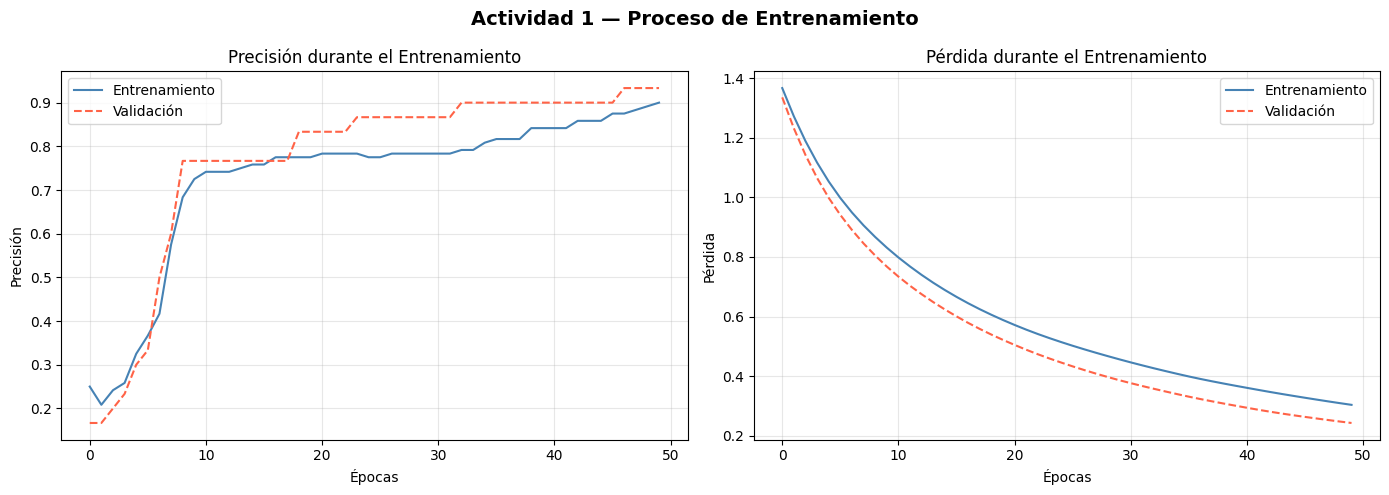

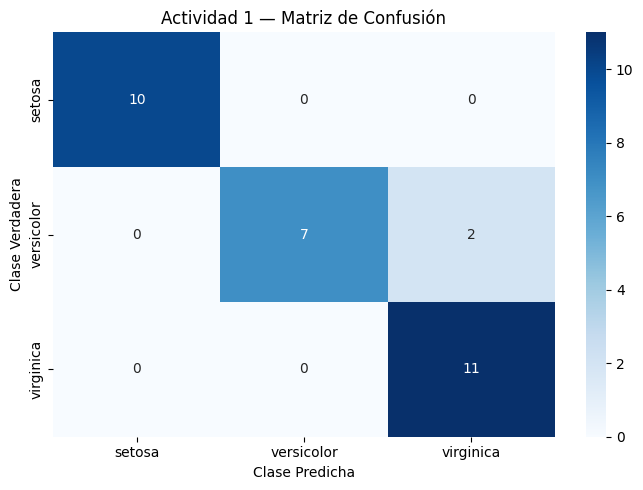


Reporte de Clasificación — Actividad 1:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.78      0.88         9
   virginica       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [6]:
# ============================================================
# ACTIVIDAD 1 — PARTE C: VISUALIZACIÓN DEL ENTRENAMIENTO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actividad 1 — Proceso de Entrenamiento', fontsize=14, fontweight='bold')

# --- Gráfico de Precisión ---
axes[0].plot(history_act1.history['accuracy'],     label='Entrenamiento', color='steelblue')
axes[0].plot(history_act1.history['val_accuracy'], label='Validación',    color='tomato', linestyle='--')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Precisión')
axes[0].set_title('Precisión durante el Entrenamiento')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Gráfico de Pérdida ---
axes[1].plot(history_act1.history['loss'],     label='Entrenamiento', color='steelblue')
axes[1].plot(history_act1.history['val_loss'], label='Validación',    color='tomato', linestyle='--')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Pérdida')
axes[1].set_title('Pérdida durante el Entrenamiento')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ACTIVIDAD 1 — PARTE D: MATRIZ DE CONFUSIÓN
# ============================================================

conf_matrix_act1 = confusion_matrix(y_test, predictions_act1)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_act1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Actividad 1 — Matriz de Confusión')
plt.tight_layout()
plt.show()

# Imprimir reporte de clasificación detallado
print("\nReporte de Clasificación — Actividad 1:")
print(classification_report(y_test, predictions_act1, target_names=iris.target_names))

---
## Actividad 2 — Entrenamiento y Ajuste de Parámetros

**Objetivo:** Comprender cómo las redes neuronales "aprenden" ajustando pesos y minimizando el error  
mediante aprendizaje supervisado.

**Enfoque:**
- Entrenar el mismo modelo con tres tasas de aprendizaje distintas: `0.01`, `0.001`, `0.0001`.
- Comparar visualmente la convergencia y la precisión final.

> **Concepto clave:** La *tasa de aprendizaje* (learning rate) controla el tamaño del paso  
> al descender por el gradiente. Muy alta → inestabilidad; muy baja → convergencia lenta.

In [7]:
# ============================================================
# ACTIVIDAD 2 — ENTRENAMIENTO CON DIFERENTES TASAS DE APRENDIZAJE
# ============================================================

learning_rates = [0.01, 0.001, 0.0001]
histories_act2   = []   # Almacena los objetos History de cada modelo
accuracies_act2  = []   # Almacena la precisión final de cada modelo

for lr in learning_rates:
    print(f"Entrenando con tasa de aprendizaje: {lr} ...", end=' ')

    # Crear un modelo nuevo para cada experimento
    # (evita que los pesos del modelo anterior influyan en el nuevo)
    model_lr = Sequential([
        Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(3, activation='softmax')
    ])

    # Compilar con el optimizador Adam configurado con la tasa de aprendizaje específica
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model_lr.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar y guardar el historial
    history_lr = model_lr.fit(
        X_train, y_train,
        epochs=50,
        batch_size=8,
        verbose=0,
        validation_data=(X_test, y_test)
    )
    histories_act2.append(history_lr)

    # Evaluar la precisión en el conjunto de prueba
    preds_lr = model_lr.predict(X_test, verbose=0).argmax(axis=1)
    acc_lr   = accuracy_score(y_test, preds_lr)
    accuracies_act2.append(acc_lr)

    print(f"Precisión: {acc_lr:.4f}")

print("\nEntrenamiento completado para todas las tasas.")

Entrenando con tasa de aprendizaje: 0.01 ... Precisión: 1.0000
Entrenando con tasa de aprendizaje: 0.001 ... Precisión: 0.9667
Entrenando con tasa de aprendizaje: 0.0001 ... Precisión: 0.5333

Entrenamiento completado para todas las tasas.


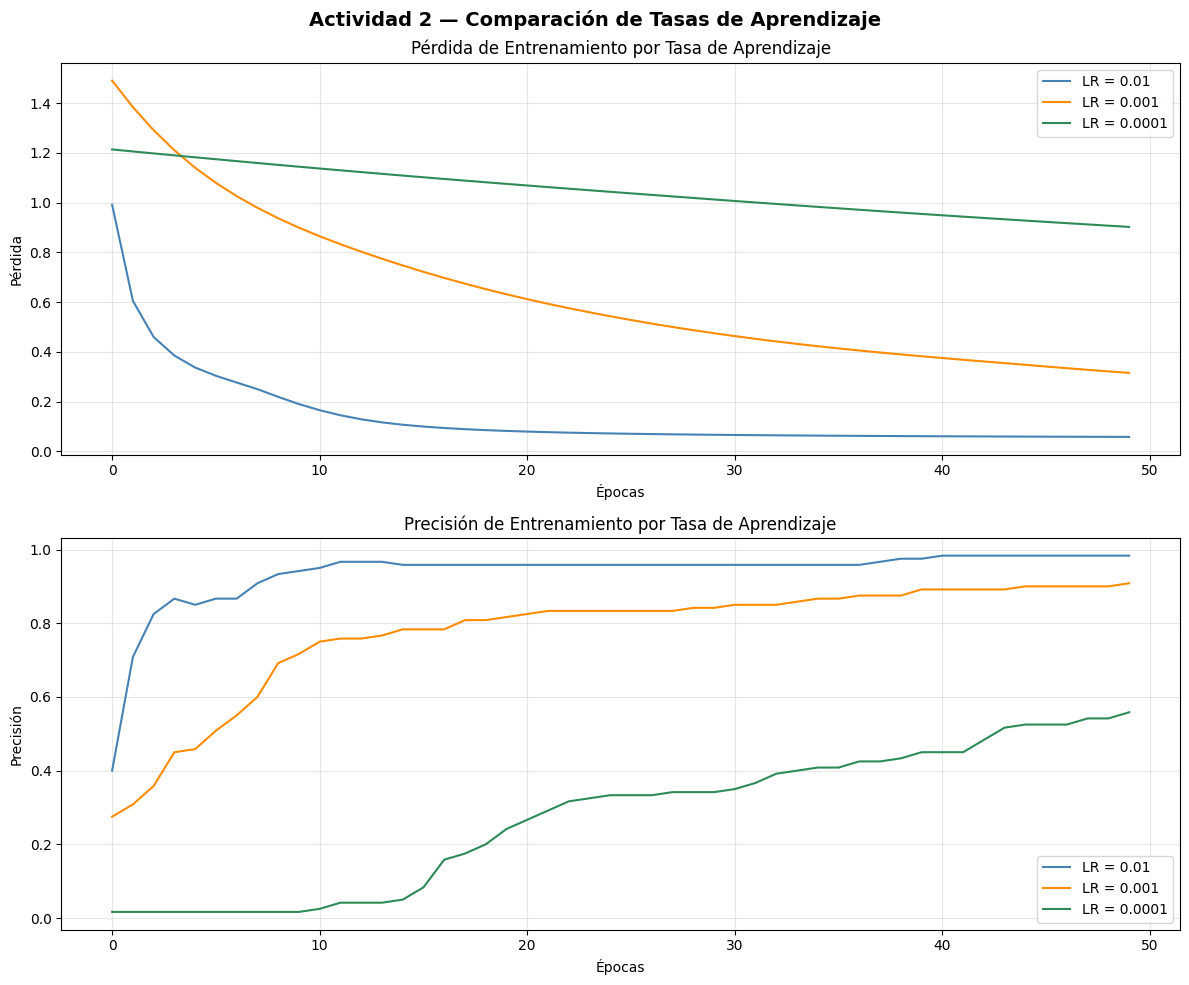

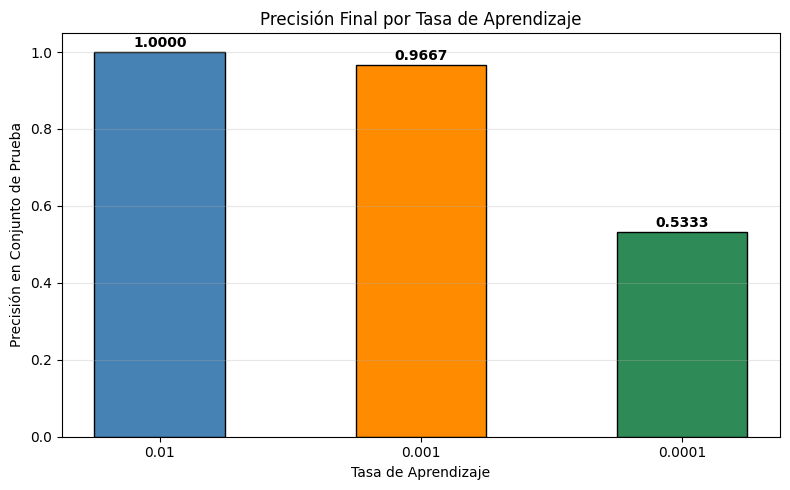

In [8]:
# ============================================================
# ACTIVIDAD 2 — VISUALIZACIÓN COMPARATIVA
# ============================================================

colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Actividad 2 — Comparación de Tasas de Aprendizaje', fontsize=14, fontweight='bold')

# --- Pérdida por tasa de aprendizaje ---
for i, lr in enumerate(learning_rates):
    axes[0].plot(
        histories_act2[i].history['loss'],
        label=f'LR = {lr}',
        color=colors[i]
    )
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida de Entrenamiento por Tasa de Aprendizaje')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Precisión por tasa de aprendizaje ---
for i, lr in enumerate(learning_rates):
    axes[1].plot(
        histories_act2[i].history['accuracy'],
        label=f'LR = {lr}',
        color=colors[i]
    )
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión de Entrenamiento por Tasa de Aprendizaje')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Gráfico de barras: precisión final en test ---
plt.figure(figsize=(8, 5))
bars = plt.bar(
    [str(lr) for lr in learning_rates],
    accuracies_act2,
    color=colors,
    edgecolor='black',
    width=0.5
)
# Añadir etiquetas de valor en cada barra
for bar, acc in zip(bars, accuracies_act2):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc:.4f}',
        ha='center', va='bottom', fontweight='bold'
    )
plt.xlabel('Tasa de Aprendizaje')
plt.ylabel('Precisión en Conjunto de Prueba')
plt.title('Precisión Final por Tasa de Aprendizaje')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Actividad 3 — Regularización para Mejorar la Generalización

**Objetivo:** Prevenir el sobreajuste mediante técnicas de regularización.

**Técnicas aplicadas:**
- **L2 (Ridge):** Penaliza pesos grandes sumando λ·||w||² a la función de pérdida.  
  Reduce la magnitud de todos los pesos, simplificando el modelo.
- **Dropout:** Desactiva aleatoriamente un porcentaje de neuronas en cada iteración,  
  forzando a la red a aprender representaciones más robustas y distribuidas.

> Se compara el rendimiento **con** y **sin** regularización para cuantificar su impacto.

In [9]:
# ============================================================
# ACTIVIDAD 3 — MODELO CON REGULARIZACIÓN L2 + DROPOUT
# ============================================================

# --- Modelo SIN regularización (línea base) ---
model_baseline = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(3, activation='softmax')
], name='baseline')

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=50, batch_size=8,
    validation_data=(X_test, y_test),
    verbose=0
)

# --- Modelo CON regularización L2 + Dropout ---
model_reg = Sequential([
    # kernel_regularizer=l2(0.01): añade penalización L2 sobre los pesos de esta capa
    Dense(
        10,
        activation='relu',
        kernel_regularizer=l2(0.01),
        input_shape=(X_train.shape[1],)
    ),
    # Dropout(0.3): apaga el 30% de las neuronas aleatoriamente en cada batch
    # Solo activo durante el entrenamiento; en inferencia todas las neuronas participan
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='con_regularizacion')

model_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_reg = model_reg.fit(
    X_train, y_train,
    epochs=50, batch_size=8,
    validation_data=(X_test, y_test),
    verbose=0
)

# Evaluar ambos modelos
_, acc_baseline = model_baseline.evaluate(X_test, y_test, verbose=0)
_, acc_reg      = model_reg.evaluate(X_test, y_test, verbose=0)

print(f"Precisión SIN regularización: {acc_baseline:.4f}")
print(f"Precisión CON regularización (L2 + Dropout): {acc_reg:.4f}")

Precisión SIN regularización: 0.9667
Precisión CON regularización (L2 + Dropout): 0.8333


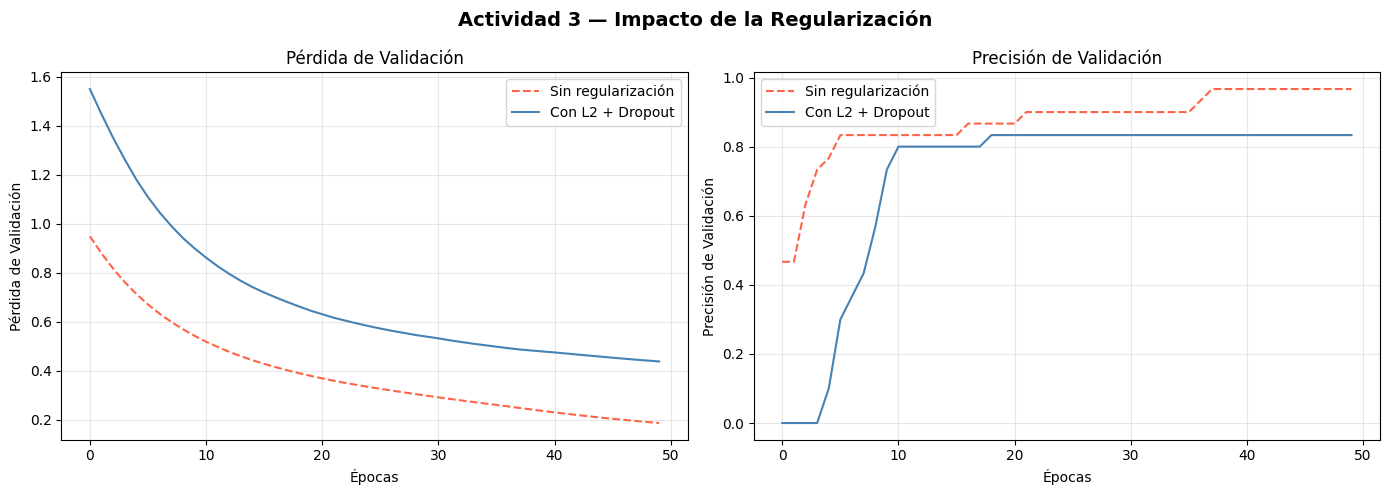

In [10]:
# ============================================================
# ACTIVIDAD 3 — COMPARACIÓN VISUAL: CON vs. SIN REGULARIZACIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actividad 3 — Impacto de la Regularización', fontsize=14, fontweight='bold')

# Pérdida de validación: indicador principal de generalización
axes[0].plot(history_baseline.history['val_loss'], label='Sin regularización', color='tomato', linestyle='--')
axes[0].plot(history_reg.history['val_loss'],      label='Con L2 + Dropout',   color='steelblue')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida de Validación')
axes[0].set_title('Pérdida de Validación')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precisión de validación
axes[1].plot(history_baseline.history['val_accuracy'], label='Sin regularización', color='tomato', linestyle='--')
axes[1].plot(history_reg.history['val_accuracy'],      label='Con L2 + Dropout',   color='steelblue')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión de Validación')
axes[1].set_title('Precisión de Validación')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Actividad 4 — Optimización Avanzada con Técnicas de Ajuste

**Objetivo:** Optimizar el modelo mediante búsqueda sistemática de hiperparámetros.

**Métodos:**
- **Grid Search:** Prueba exhaustivamente todas las combinaciones del espacio definido.
- **Random Search:** Muestrea aleatoriamente combinaciones; más eficiente para espacios grandes.

**Hiperparámetros a explorar:** número de neuronas, función de activación, dropout, tasa de aprendizaje.

> ⚠️ **Nota de compatibilidad:** `KerasClassifier` fue movido a `scikeras` en versiones recientes.  
> Se utiliza `scikeras.wrappers.KerasClassifier` como reemplazo directo y moderno.

In [11]:
# scikeras es el reemplazo oficial de tensorflow.keras.wrappers.scikit_learn
# que fue deprecado y eliminado en TF 2.12+
# !pip install scikeras -q

In [12]:
# ============================================================
# ACTIVIDAD 4 — GRID SEARCH CON SCIKERAS
# ============================================================

# CORRECCIÓN: Se reemplaza el deprecado tensorflow.keras.wrappers.scikit_learn
# por scikeras.wrappers, que es la solución oficial y compatible con TF 2.x
from scikeras.wrappers import KerasClassifier

def create_model(activation='relu', dropout_rate=0.0, neurons=10, learning_rate=0.001):
    """
    Fábrica de modelos parametrizable para usar con GridSearchCV / RandomizedSearchCV.
    
    Parámetros
    ----------
    activation    : str   — función de activación de la capa oculta
    dropout_rate  : float — porcentaje de neuronas a desactivar (0.0 = sin dropout)
    neurons       : int   — número de neuronas en la capa oculta
    learning_rate : float — tasa de aprendizaje del optimizador Adam

    Retorna
    -------
    model : tf.keras.Model compilado
    """
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))

    # Dropout se aplica solo si la tasa es mayor que 0
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(3, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Envolver el modelo Keras en un clasificador compatible con scikit-learn
# model__* sirve para pasar parámetros a la función create_model
keras_clf = KerasClassifier(
    model=create_model,
    epochs=50,
    batch_size=8,
    verbose=0
)

# Espacio de hiperparámetros a explorar
# Cada clave sigue el formato 'model__<nombre_parametro>'
param_grid = {
    'model__neurons':       [10, 20, 30],
    'model__activation':    ['relu', 'tanh'],
    'model__dropout_rate':  [0.0, 0.3, 0.5],
    'model__learning_rate': [0.01, 0.001]
}

# GridSearchCV: evalúa todas las combinaciones con validación cruzada de 3 pliegues
# cv=3: equilibrio entre robustez y tiempo de cómputo para un dataset pequeño
grid = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=3,
    n_jobs=1,          # n_jobs=1 para compatibilidad con TF (evita conflictos de subprocesos)
    scoring='accuracy'
)

print("Ejecutando Grid Search (puede tomar varios minutos)...")
grid_result = grid.fit(X_train, y_train)

print(f"\nMejores parámetros (Grid Search): {grid_result.best_params_}")
print(f"Mejor puntuación CV:              {grid_result.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_preds_grid = grid_result.best_estimator_.predict(X_test)
print("\nReporte — Mejor modelo (Grid Search):")
print(classification_report(y_test, best_preds_grid, target_names=iris.target_names))

Ejecutando Grid Search (puede tomar varios minutos)...

Mejores parámetros (Grid Search): {'model__activation': 'relu', 'model__dropout_rate': 0.0, 'model__learning_rate': 0.01, 'model__neurons': 10}
Mejor puntuación CV:              0.9583

Reporte — Mejor modelo (Grid Search):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
# ============================================================
# ACTIVIDAD 4 — RANDOM SEARCH
# ============================================================

# Espacio de distribución más amplio que el de Grid Search
# Random Search explora este espacio de forma aleatoria (n_iter combinaciones)
param_distributions = {
    'model__neurons':       [10, 20, 30, 40, 50],
    'model__activation':    ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate':  [0.0, 0.2, 0.3, 0.5],
    'model__learning_rate': [0.1, 0.01, 0.001, 0.0001]
}

# Crear un nuevo clasificador base para Random Search
keras_clf_rs = KerasClassifier(
    model=create_model,
    epochs=50,
    batch_size=8,
    verbose=0
)

# n_iter=10: número de combinaciones aleatorias a probar
# Mucho más rápido que Grid Search cuando el espacio de parámetros es grande
random_search = RandomizedSearchCV(
    estimator=keras_clf_rs,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    n_jobs=1,
    random_state=RANDOM_STATE,
    scoring='accuracy'
)

print("Ejecutando Random Search (puede tomar varios minutos)...")
random_result = random_search.fit(X_train, y_train)

print(f"\nMejores parámetros (Random Search): {random_result.best_params_}")
print(f"Mejor puntuación CV:                {random_result.best_score_:.4f}")

best_preds_random = random_result.best_estimator_.predict(X_test)
print("\nReporte — Mejor modelo (Random Search):")
print(classification_report(y_test, best_preds_random, target_names=iris.target_names))

Ejecutando Random Search (puede tomar varios minutos)...

Mejores parámetros (Random Search): {'model__neurons': 40, 'model__learning_rate': 0.1, 'model__dropout_rate': 0.5, 'model__activation': 'tanh'}
Mejor puntuación CV:                0.9750

Reporte — Mejor modelo (Random Search):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



---
## Actividad 5 — Evaluación y Métricas de Desempeño

**Objetivo:** Evaluar el modelo final con métricas adecuadas y detectar sobreajuste/subajuste.

**Métricas utilizadas:**
- **Precisión (Precision):** TP / (TP + FP) — ¿qué tan fiables son las predicciones positivas?
- **Recall (Sensibilidad):** TP / (TP + FN) — ¿cuántos positivos reales se detectaron?
- **F1-score:** media armónica de precisión y recall.
- **Curva ROC / AUC:** mide la capacidad discriminativa del modelo a distintos umbrales.
- **Curvas de aprendizaje:** diagnostican sobreajuste y subajuste.

Reporte de Clasificación — Actividad 5:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.44      0.62         9
   virginica       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30



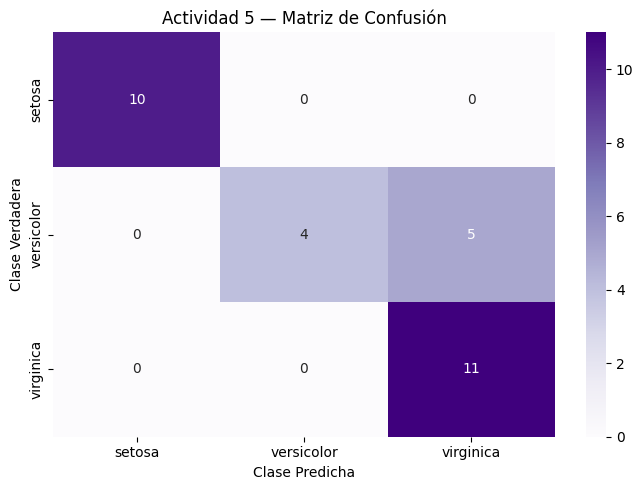

In [14]:
# ============================================================
# ACTIVIDAD 5 — EVALUACIÓN COMPLETA DEL MODELO
# Usamos el modelo con regularización entrenado en la Actividad 3
# como modelo de referencia para la evaluación.
# ============================================================

# Predicciones del modelo regularizado
y_pred_act5 = model_reg.predict(X_test, verbose=0).argmax(axis=1)

# Reporte de clasificación: precisión, recall y F1 por clase
print("Reporte de Clasificación — Actividad 5:")
print(classification_report(y_test, y_pred_act5, target_names=iris.target_names))

# Matriz de confusión
conf_matrix_act5 = confusion_matrix(y_test, y_pred_act5)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix_act5,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Actividad 5 — Matriz de Confusión')
plt.tight_layout()
plt.show()

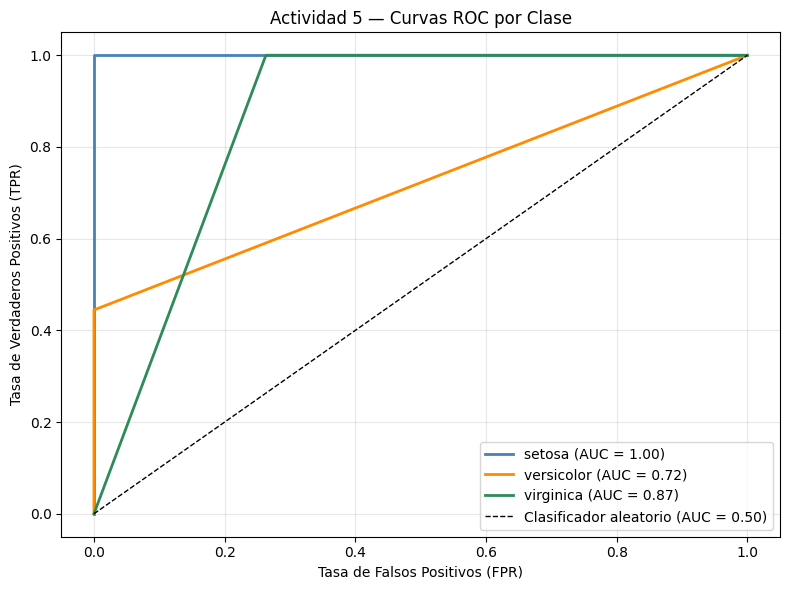


AUC promedio (macro): 0.8635


In [15]:
# ============================================================
# ACTIVIDAD 5 — CURVAS ROC POR CLASE (Enfoque One-vs-Rest)
# ============================================================
# Para problemas multiclase se usa la estrategia One-vs-Rest:
# cada clase se evalúa como "esa clase" vs "todas las demás".

n_classes = 3
fpr, tpr, roc_auc_scores = {}, {}, {}

for i in range(n_classes):
    # Convertir a problema binario: ¿es la clase i o no?
    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred_act5 == i).astype(int)

    fpr[i], tpr[i], _ = roc_curve(y_true_bin, y_pred_bin)
    roc_auc_scores[i] = auc(fpr[i], tpr[i])

# Graficar curvas ROC para cada clase
roc_colors = ['steelblue', 'darkorange', 'seagreen']
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        label=f'{iris.target_names[i]} (AUC = {roc_auc_scores[i]:.2f})',
        color=roc_colors[i],
        lw=2
    )

# Línea diagonal de referencia (clasificador aleatorio AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.50)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Actividad 5 — Curvas ROC por Clase')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC promedio macro
mean_auc = np.mean(list(roc_auc_scores.values()))
print(f"\nAUC promedio (macro): {mean_auc:.4f}")

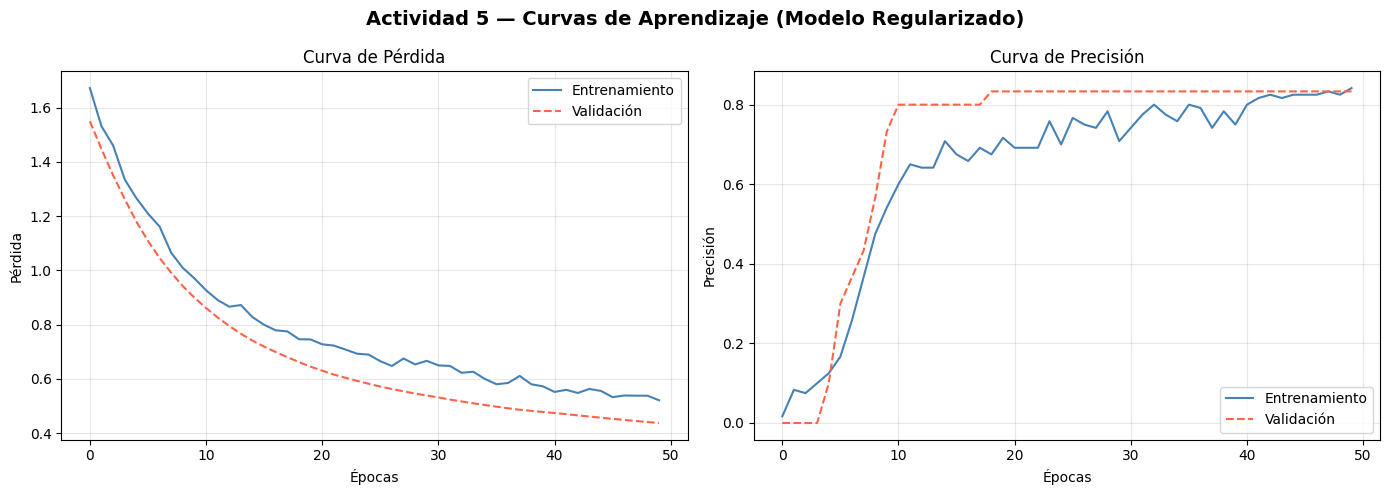

Precisión final — Entrenamiento: 0.8417
Precisión final — Validación:    0.8333
Brecha (gap):                    0.0083
✅ El modelo parece generalizar correctamente.


In [16]:
# ============================================================
# ACTIVIDAD 5 — CURVAS DE APRENDIZAJE
# Comparación entre curva de entrenamiento y validación para
# diagnosticar sobreajuste (gap grande) o subajuste (pérdida alta en ambas).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actividad 5 — Curvas de Aprendizaje (Modelo Regularizado)', fontsize=14, fontweight='bold')

# Pérdida
axes[0].plot(history_reg.history['loss'],     label='Entrenamiento', color='steelblue')
axes[0].plot(history_reg.history['val_loss'], label='Validación',    color='tomato', linestyle='--')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Curva de Pérdida')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precisión
axes[1].plot(history_reg.history['accuracy'],     label='Entrenamiento', color='steelblue')
axes[1].plot(history_reg.history['val_accuracy'], label='Validación',    color='tomato', linestyle='--')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva de Precisión')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico automático de sobreajuste
final_train_acc = history_reg.history['accuracy'][-1]
final_val_acc   = history_reg.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"Precisión final — Entrenamiento: {final_train_acc:.4f}")
print(f"Precisión final — Validación:    {final_val_acc:.4f}")
print(f"Brecha (gap):                    {gap:.4f}")

if gap > 0.1:
    print("⚠️  Posible SOBREAJUSTE detectado (gap > 0.10). Considerar más regularización.")
elif final_val_acc < 0.7:
    print("⚠️  Posible SUBAJUSTE detectado (val_acc < 0.70). Considerar más capacidad o más épocas.")
else:
    print("✅ El modelo parece generalizar correctamente.")

---
## 🏆 Reto — Predicción de Churn en Clientes de Telecomunicaciones

**Dataset:** Telco Customer Churn (IBM / Kaggle)  
**Objetivo:** Predecir si un cliente cancelará su suscripción (`Churn = Yes/No`).

### Fases del Reto

| Fase | Descripción | Entregable |
|------|-------------|------------|
| 1 | Preprocesamiento y EDA | Notebook con transformaciones justificadas |
| 2 | Construcción de la Red Neuronal | Código + curvas de entrenamiento |
| 3 | Optimización y Regularización | Comparativa antes/después + mejores hiperparámetros |
| 4 | Evaluación del Modelo | Reporte con ROC-AUC, F1-score, matriz de confusión |
| 5 | Comunicación de Resultados | Presentación PDF/PPT con conclusiones de negocio |

In [25]:
# ============================================================
# RETO — FASE 1: DESCARGA Y CARGA DEL DATASET
# ============================================================

# Opción A: descarga automática via kagglehub (requiere credenciales de Kaggle)
# Opción B: descarga manual desde https://www.kaggle.com/datasets/blastchar/telco-customer-churn
#           y colocar el CSV en el directorio de trabajo.

try:
    import kagglehub
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    print(f"Dataset descargado en: {path}")
    telco_data = pd.read_csv(path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset cargado exitosamente via kagglehub.")
except Exception as e:
    print(f"kagglehub no disponible o fallo en descarga: {e}")
    print("Intentando cargar desde archivo local...")
    try:
        # CORRECCIÓN: ruta local como fallback
        telco_data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
        print("Dataset cargado desde archivo local.")
    except FileNotFoundError:
        print("\n⚠️  Archivo no encontrado.")
        print("Descarga el dataset desde: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
        print("y coloca el CSV en el mismo directorio que este notebook.")
        # Crear datos sintéticos para que el resto del notebook sea ejecutable
        print("\nGenerando datos sintéticos para demostración...")
        np.random.seed(RANDOM_STATE)
        n = 500
        telco_data = pd.DataFrame({
            'customerID':      [f'ID_{i}' for i in range(n)],
            'gender':          np.random.choice(['Male', 'Female'], n),
            'SeniorCitizen':   np.random.randint(0, 2, n),
            'Partner':         np.random.choice(['Yes', 'No'], n),
            'Dependents':      np.random.choice(['Yes', 'No'], n),
            'tenure':          np.random.randint(0, 72, n),
            'MonthlyCharges':  np.round(np.random.uniform(18, 120, n), 2),
            'TotalCharges':    np.round(np.random.uniform(0, 8500, n), 2),
            'Contract':        np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
            'PaymentMethod':   np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n),
            'Churn':           np.random.choice(['Yes', 'No'], n, p=[0.27, 0.73])
        })
        print(f"Dataset sintético creado: {telco_data.shape}")

print(f"\nDimensiones: {telco_data.shape}")
telco_data.head()

kagglehub no disponible o fallo en descarga: No module named 'kagglehub'
Intentando cargar desde archivo local...

⚠️  Archivo no encontrado.
Descarga el dataset desde: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
y coloca el CSV en el mismo directorio que este notebook.

Generando datos sintéticos para demostración...
Dataset sintético creado: (500, 11)

Dimensiones: (500, 11)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,Churn
0,ID_0,Male,0,No,Yes,46,38.59,4235.17,Month-to-month,Mailed check,No
1,ID_1,Female,0,Yes,No,11,86.69,655.00,Month-to-month,Mailed check,Yes
2,ID_2,Male,0,Yes,No,61,116.93,497.68,Month-to-month,Mailed check,Yes
3,ID_3,Male,1,Yes,Yes,7,27.58,2841.03,Month-to-month,Mailed check,No
4,ID_4,Male,0,Yes,Yes,20,86.61,6671.62,Month-to-month,Mailed check,No


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      500 non-null    object 
 1   gender          500 non-null    object 
 2   SeniorCitizen   500 non-null    int64  
 3   Partner         500 non-null    object 
 4   Dependents      500 non-null    object 
 5   tenure          500 non-null    int64  
 6   MonthlyCharges  500 non-null    float64
 7   TotalCharges    500 non-null    float64
 8   Contract        500 non-null    object 
 9   PaymentMethod   500 non-null    object 
 10  Churn           500 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 43.1+ KB
None

VALORES NULOS POR COLUMNA
customerID        0
gender            0
SeniorCitizen     0
Partner           0
Dependents        0
tenure            0
MonthlyCharges    0
TotalCharges      0
Contract          0
Pay

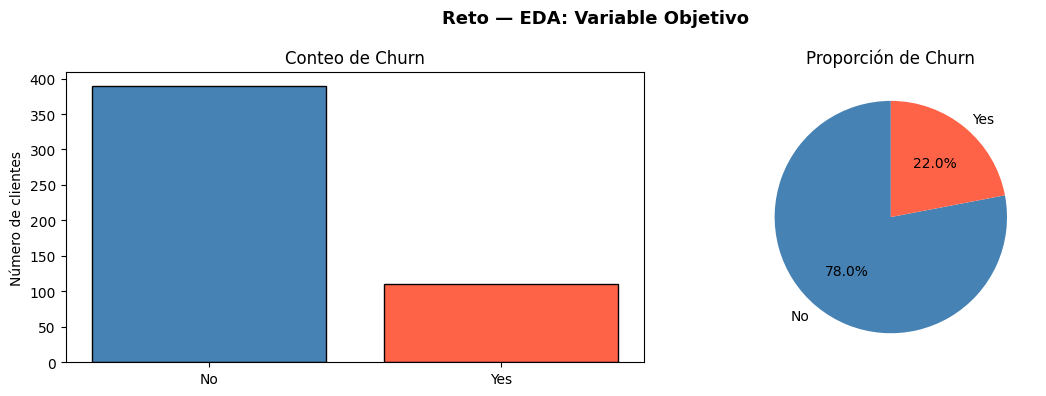

In [18]:
# ============================================================
# RETO — FASE 1: ANÁLISIS EXPLORATORIO (EDA)
# ============================================================

print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(telco_data.info())

print("\n" + "=" * 50)
print("VALORES NULOS POR COLUMNA")
print("=" * 50)
print(telco_data.isnull().sum())

print("\n" + "=" * 50)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Churn)")
print("=" * 50)
print(telco_data['Churn'].value_counts())
print(f"\nTasa de churn: {telco_data['Churn'].value_counts(normalize=True)['Yes']:.2%}")

# Visualizar distribución de Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Reto — EDA: Variable Objetivo', fontsize=13, fontweight='bold')

churn_counts = telco_data['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Conteo de Churn')
axes[0].set_ylabel('Número de clientes')

axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Proporción de Churn')

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# RETO — FASE 1: PREPROCESAMIENTO DE DATOS
# ============================================================

df = telco_data.copy()  # Trabajar sobre una copia para preservar los datos originales

# 1. Eliminar columna ID (no aporta información predictiva)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 2. Convertir TotalCharges a numérico
# CORRECCIÓN: TotalCharges puede contener espacios en blanco que generan NaN
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Imputar valores nulos con la mediana (robusto ante outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Imputado '{col}' con mediana={median_val:.2f}")

# 4. Codificar variable objetivo
# Churn: 'Yes' → 1 (cliente canceló), 'No' → 0 (cliente activo)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 5. Codificar variables categóricas con One-Hot Encoding
# drop_first=True elimina una columna por variable para evitar multicolinealidad perfecta
df = pd.get_dummies(df, drop_first=True)

print(f"\nDimensiones tras preprocesamiento: {df.shape}")
print(f"Columnas: {list(df.columns)}")

# 6. Separar features y target
X_churn = df.drop(columns=['Churn']).values
y_churn = df['Churn'].values

# 7. Dividir en entrenamiento (80%) y prueba (20%)
# stratify=y_churn mantiene la proporción de clases en ambas particiones
X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
    X_churn, y_churn,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_churn  # CORRECCIÓN: importante para datasets desbalanceados
)

# 8. Escalar características
scaler_churn = StandardScaler()
X_churn_train = scaler_churn.fit_transform(X_churn_train)
X_churn_test  = scaler_churn.transform(X_churn_test)

print(f"\nEntrenamiento: {X_churn_train.shape[0]} muestras")
print(f"Prueba:        {X_churn_test.shape[0]} muestras")
print(f"Features:      {X_churn_train.shape[1]}")


Dimensiones tras preprocesamiento: (500, 13)
Columnas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Entrenamiento: 400 muestras
Prueba:        100 muestras
Features:      12


In [20]:
# ============================================================
# RETO — FASE 2: CONSTRUCCIÓN Y ENTRENAMIENTO DE LA RED NEURONAL
# ============================================================

n_features_churn = X_churn_train.shape[1]

# Arquitectura para clasificación binaria:
# Capa de salida: 1 neurona con activación sigmoide → probabilidad de churn
# Función de pérdida: binary_crossentropy (adecuada para clasificación binaria)
model_churn = Sequential([
    Dense(64, activation='relu', input_shape=(n_features_churn,)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')   # Salida binaria: probabilidad de Churn
], name='churn_predictor')

model_churn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',      # Función de pérdida para clasificación binaria
    metrics=['accuracy']
)

model_churn.summary()

# Callback: Early Stopping — detiene el entrenamiento si val_loss no mejora
# en 'patience' épocas consecutivas, y restaura los mejores pesos
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_churn = model_churn.fit(
    X_churn_train, y_churn_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_churn_test, y_churn_test),
    callbacks=[early_stopping],
    verbose=0
)

epochs_run = len(history_churn.history['loss'])
print(f"Entrenamiento completado. Épocas ejecutadas: {epochs_run}")

Model: "churn_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_292 (Dense)               │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_90 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_294 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento completado. Épocas ejecutadas: 54


Reporte de Clasificación — Predicción de Churn:
              precision    recall  f1-score   support

    No Churn       0.78      1.00      0.88        78
       Churn       0.00      0.00      0.00        22

    accuracy                           0.78       100
   macro avg       0.39      0.50      0.44       100
weighted avg       0.61      0.78      0.68       100



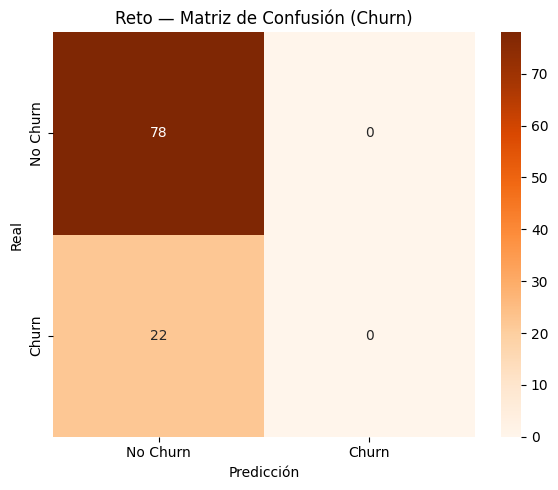

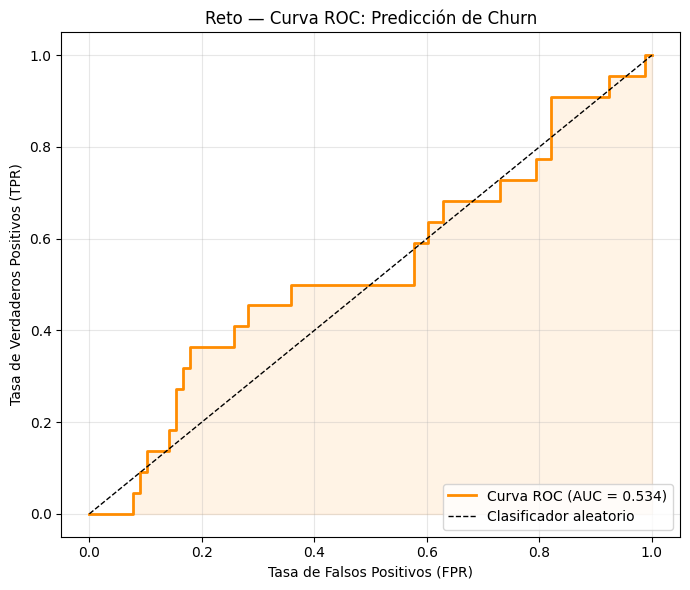

AUC del modelo de churn: 0.5344


In [21]:
# ============================================================
# RETO — FASE 4: EVALUACIÓN DEL MODELO DE CHURN
# ============================================================

# Predicciones: probabilidades y clases
y_prob_churn = model_churn.predict(X_churn_test, verbose=0).ravel()
y_pred_churn = (y_prob_churn >= 0.5).astype(int)  # Umbral estándar de 0.5

# Reporte de clasificación
print("Reporte de Clasificación — Predicción de Churn:")
print(classification_report(y_churn_test, y_pred_churn, target_names=['No Churn', 'Churn']))

# Matriz de confusión
plt.figure(figsize=(6, 5))
cm_churn = confusion_matrix(y_churn_test, y_pred_churn)
sns.heatmap(
    cm_churn,
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Reto — Matriz de Confusión (Churn)')
plt.tight_layout()
plt.show()

# Curva ROC y AUC
# Para clasificación binaria, roc_curve espera probabilidades (no clases predichas)
fpr_churn, tpr_churn, _ = roc_curve(y_churn_test, y_prob_churn)
auc_churn = auc(fpr_churn, tpr_churn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_churn, tpr_churn, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_churn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
plt.fill_between(fpr_churn, tpr_churn, alpha=0.1, color='darkorange')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Reto — Curva ROC: Predicción de Churn')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC del modelo de churn: {auc_churn:.4f}")

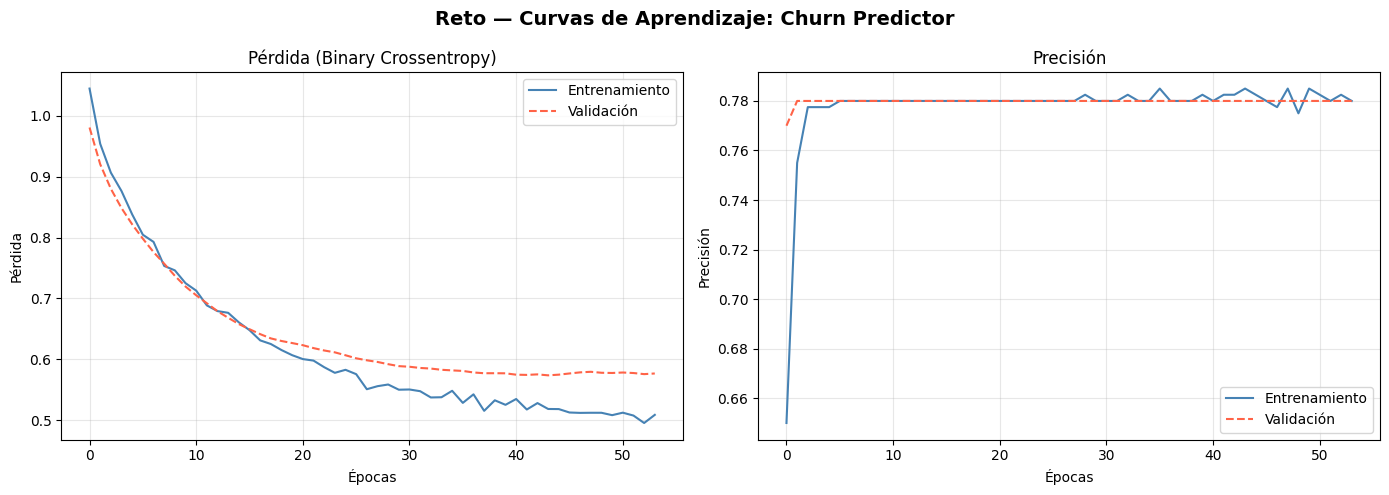

In [22]:
# ============================================================
# RETO — CURVAS DE APRENDIZAJE DEL MODELO DE CHURN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reto — Curvas de Aprendizaje: Churn Predictor', fontsize=14, fontweight='bold')

axes[0].plot(history_churn.history['loss'],     label='Entrenamiento', color='steelblue')
axes[0].plot(history_churn.history['val_loss'], label='Validación',    color='tomato', linestyle='--')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_churn.history['accuracy'],     label='Entrenamiento', color='steelblue')
axes[1].plot(history_churn.history['val_accuracy'], label='Validación',    color='tomato', linestyle='--')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📊 Resumen del Laboratorio

| Actividad | Técnica Principal | Resultado Esperado |
|-----------|-------------------|--------------------|
| 1 — Red Simple | Sequential + Dense (ReLU / Softmax) | Clasificación correcta de Iris |
| 2 — Ajuste de Parámetros | Comparación de Learning Rates | Identificar LR óptima |
| 3 — Regularización | L2 + Dropout | Reducir brecha train/val |
| 4 — Optimización | Grid Search / Random Search | Mejores hiperparámetros |
| 5 — Evaluación | ROC-AUC, F1, Curvas de Aprendizaje | Diagnóstico completo del modelo |
| Reto | Pipeline completo sobre Churn | Modelo listo para producción |

### 🔑 Conceptos Clave Consolidados

- **Retropropagación:** propaga el error desde la capa de salida hacia la entrada para ajustar pesos.
- **Descenso del gradiente:** minimiza la función de pérdida moviéndose en la dirección de mayor descenso.
- **Sobreajuste:** el modelo aprende el ruido del entrenamiento; se mitiga con L1/L2/Dropout.
- **Subajuste:** el modelo es demasiado simple; se corrige añadiendo capas o neuronas.
- **Validación cruzada k-fold:** estimación más robusta del rendimiento real del modelo.
- **AUC-ROC:** métrica de ranking; indica cuánto mejor es el modelo que un clasificador aleatorio.